# Movie Data Analysis with PySpark

This notebook presents an end-to-end big data analytics workflow using PySpark, Spark SQL and machine learning.

The original code has been preserved. Only Markdown headings and documentation have been added for readability.


## 1. Environment Setup

Import required libraries and initialise the Spark environment.


In [1]:
#import the library and function
from pyspark import SparkConf
from pyspark.context import SparkContext
from pyspark.sql import *
from pyspark.sql.functions import *
from pyspark.sql.types import *
import pandas as pd 
import matplotlib.pyplot as plt

sc = SparkContext.getOrCreate(SparkConf().setMaster("local[*]"))
#spark app
spark = SparkSession.builder.appName("s4782076_Individual_Project").getOrCreate()
#store data in the variable
path = "hdfs://namenode:9000/individual_project/data.csv"
path2 = "hdfs://namenode:9000/individual_project/movies_tmdb_popular.csv"
data = spark.read.csv(path, header=True, inferSchema=True)
tmdata= spark.read.csv(path2, header=True, inferSchema=True)

## 2. Dataset Overview

Inspect dataset columns, records and schema.


In [2]:
#list the column
columns = data.columns
columns
tmcolumns = tmdata.columns
tmcolumns

['title',
 'overview',
 'original_lang',
 'rel_date',
 'popularity',
 'vote_count',
 'vote_average']

In [3]:
#check these two dataset
data.show()

print('-' * 30)

tmdata.show()

+---+--------------------+---------------+-------------------+------------+-------+---------+---------+--------------------+-------------+--------------------+--------------------+--------------------+
|_c0|          Movie Name|Year of Release|Run Time in minutes|Movie Rating|  Votes|MetaScore|    Gross|               Genre|Certification|            Director|               Stars|         Description|
+---+--------------------+---------------+-------------------+------------+-------+---------+---------+--------------------+-------------+--------------------+--------------------+--------------------+
|  0|The Shawshank Red...|           1994|                142|         9.3|2804443|     82.0|  2.834E7|           ['Drama']|            R|  ['Frank Darabont']|['Tim Robbins', '...|['Over', 'the', '...|
|  1|       The Godfather|           1972|                175|         9.2|1954174|    100.0| 1.3497E8| ['Crime', ' Drama']|            R|['Francis Ford Co...|['Marlon Brando',...|['Don', 'Vit

In [4]:
#check data information
data.describe().show()

+-------+------------------+--------------------+----------------+-------------------+------------------+-----------------+------------------+-------------------+--------------------+-------------+-------------------+--------------------+--------------------+
|summary|               _c0|          Movie Name| Year of Release|Run Time in minutes|      Movie Rating|            Votes|         MetaScore|              Gross|               Genre|Certification|           Director|               Stars|         Description|
+-------+------------------+--------------------+----------------+-------------------+------------------+-----------------+------------------+-------------------+--------------------+-------------+-------------------+--------------------+--------------------+
|  count|             10000|               10000|           10000|              10000|             10000|            10000|              7974|               7085|               10000|         9631|              10000|   

In [5]:
data.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- Movie Name: string (nullable = true)
 |-- Year of Release: integer (nullable = true)
 |-- Run Time in minutes: integer (nullable = true)
 |-- Movie Rating: double (nullable = true)
 |-- Votes: integer (nullable = true)
 |-- MetaScore: double (nullable = true)
 |-- Gross: double (nullable = true)
 |-- Genre: string (nullable = true)
 |-- Certification: string (nullable = true)
 |-- Director: string (nullable = true)
 |-- Stars: string (nullable = true)
 |-- Description: string (nullable = true)



## 3. Data Quality Assessment

Check descriptive statistics, duplicates and missing values.


In [6]:
original_count = data.count()

# delete the duplicate line
data_no_duplicates = data.dropDuplicates()

# recheck the record number that n
count_after_drop_duplicates = data_no_duplicates.count()

#compare the line number to avoid the duplicate record
if original_count == count_after_drop_duplicates:
    print("DataFrame noDuplicates")
else:
    print("DataFrame Duplicates")
tmoriginal_count = tmdata.count()

# delete another data duplicates
tmdata_no_duplicates = tmdata.dropDuplicates()

# delete the duplicate line
count_after_drop_duplicates = tmdata_no_duplicates.count()

# recheck
if tmoriginal_count == count_after_drop_duplicates:
    print("DataFrame noDuplicates")
else:
    print("DataFrame Duplicates")

DataFrame noDuplicates
DataFrame noDuplicates


In [7]:
#drop all the nall value
data = data.na.drop()
tmdata = tmdata.na.drop()
# check the data
data.show()

+---+--------------------+---------------+-------------------+------------+-------+---------+---------+--------------------+-------------+--------------------+--------------------+--------------------+
|_c0|          Movie Name|Year of Release|Run Time in minutes|Movie Rating|  Votes|MetaScore|    Gross|               Genre|Certification|            Director|               Stars|         Description|
+---+--------------------+---------------+-------------------+------------+-------+---------+---------+--------------------+-------------+--------------------+--------------------+--------------------+
|  0|The Shawshank Red...|           1994|                142|         9.3|2804443|     82.0|  2.834E7|           ['Drama']|            R|  ['Frank Darabont']|['Tim Robbins', '...|['Over', 'the', '...|
|  1|       The Godfather|           1972|                175|         9.2|1954174|    100.0| 1.3497E8| ['Crime', ' Drama']|            R|['Francis Ford Co...|['Marlon Brando',...|['Don', 'Vit

In [8]:

import pyspark.sql.functions as F

# define the formular
pattern = r'[^\x00-\x7F]+'

# use spark sql filter data
filtered_data = data.filter(~F.col('Movie Name').rlike(pattern))

# check the data
filtered_data.show()

+---+--------------------+---------------+-------------------+------------+-------+---------+---------+--------------------+-------------+--------------------+--------------------+--------------------+
|_c0|          Movie Name|Year of Release|Run Time in minutes|Movie Rating|  Votes|MetaScore|    Gross|               Genre|Certification|            Director|               Stars|         Description|
+---+--------------------+---------------+-------------------+------------+-------+---------+---------+--------------------+-------------+--------------------+--------------------+--------------------+
|  0|The Shawshank Red...|           1994|                142|         9.3|2804443|     82.0|  2.834E7|           ['Drama']|            R|  ['Frank Darabont']|['Tim Robbins', '...|['Over', 'the', '...|
|  1|       The Godfather|           1972|                175|         9.2|1954174|    100.0| 1.3497E8| ['Crime', ' Drama']|            R|['Francis Ford Co...|['Marlon Brando',...|['Don', 'Vit

## 4. Data Cleaning

Remove duplicates, null values and invalid records.


In [9]:
# create a frame for data compare
filtered_data.createOrReplaceTempView("data_table")
tmdata.createOrReplaceTempView("tmdata_table")
#compare the data which is movie name is same to title
query = """
SELECT *
FROM data_table d
INNER JOIN tmdata_table t ON d.`Movie Name` = t.title
"""
#combine data
joined_data = spark.sql(query)
joined_data.show()

+---+--------------------+---------------+-------------------+------------+-------+---------+---------+--------------------+-------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------+--------------------+----------+------------+
|_c0|          Movie Name|Year of Release|Run Time in minutes|Movie Rating|  Votes|MetaScore|    Gross|               Genre|Certification|            Director|               Stars|         Description|               title|            overview|       original_lang|  rel_date|          popularity|vote_count|vote_average|
+---+--------------------+---------------+-------------------+------------+-------+---------+---------+--------------------+-------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------+--------------------+----------+------------+
|  0|The Shawshank Red...|           

## 5. Data Integration

Join movie datasets using Spark SQL.


In [10]:
#chang to panda cariable to draw table and graphic
df = joined_data.toPandas()
df.head()

,_c0,Movie Name,Year of Release,Run Time in minutes,Movie Rating,Votes,MetaScore,Gross,Genre,Certification,Director,Stars,Description,title,overview,original_lang,rel_date,popularity,vote_count,vote_average
0,0,The Shawshank Redemption,1994,142,9.3,2804443,82.0,28340000.0,['Drama'],R,['Frank Darabont'],"['Tim Robbins', 'Morgan Freeman', 'Bob Gunton'...","['Over', 'the', 'course', 'of', 'several', 'ye...",The Shawshank Redemption,Framed in the 1940s for the double murder of h...,en,1994-09-23,56.259,15423,8.7
1,1,The Godfather,1972,175,9.2,1954174,100.0,134970000.0,"['Crime', ' Drama']",R,['Francis Ford Coppola'],"['Marlon Brando', 'Al Pacino', 'James Caan', '...","['Don', 'Vito', 'Corleone,', 'head', 'of', 'a'...",The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",en,1972-03-14,45.162,11715,8.7
2,4,The Dark Knight,2008,152,9.0,2786129,84.0,534860000.0,"['Action', ' Crime', ' Drama']",PG-13,['Christopher Nolan'],"['Christian Bale', 'Heath Ledger', 'Aaron Eckh...","['When', 'the', 'menace', 'known', 'as', 'the'...",The Dark Knight,Batman raises the stakes in his war on crime. ...,en,2008-07-16,45.388,21489,8.4
3,5,Schindler's List,1993,195,9.0,1409869,95.0,96900000.0,"['Biography', ' Drama', ' History']",R,['Steven Spielberg'],"['Liam Neeson', 'Ralph Fiennes', 'Ben Kingsley...","['In', 'German-occupied', 'Poland', 'during', ...",Schindler's List,The true story of how businessman Oskar Schind...,en,1993-11-30,40.569,9325,8.6
4,6,The Lord of the Rings: The Return of the King,2003,201,9.0,1919908,94.0,377850000.0,"['Action', ' Adventure', ' Drama']",PG-13,['Peter Jackson'],"['Elijah Wood', 'Viggo Mortensen', 'Ian McKell...","""['Gandalf', 'and', 'Aragorn', 'lead', 'the', ...",The Lord of the Rings: The Return of the King,Aragorn is revealed as the heir to the ancient...,en,2003-12-01,60.456,14940,8.4


In [11]:
df.head(1000)

,_c0,Movie Name,Year of Release,Run Time in minutes,Movie Rating,Votes,MetaScore,Gross,Genre,Certification,Director,Stars,Description,title,overview,original_lang,rel_date,popularity,vote_count,vote_average
0,0,The Shawshank Redemption,1994,142,9.3,2804443,82.0,28340000.0,['Drama'],R,['Frank Darabont'],"['Tim Robbins', 'Morgan Freeman', 'Bob Gunton'...","['Over', 'the', 'course', 'of', 'several', 'ye...",The Shawshank Redemption,Framed in the 1940s for the double murder of h...,en,1994-09-23,56.259,15423,8.7
1,1,The Godfather,1972,175,9.2,1954174,100.0,134970000.0,"['Crime', ' Drama']",R,['Francis Ford Coppola'],"['Marlon Brando', 'Al Pacino', 'James Caan', '...","['Don', 'Vito', 'Corleone,', 'head', 'of', 'a'...",The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",en,1972-03-14,45.162,11715,8.7
2,4,The Dark Knight,2008,152,9.0,2786129,84.0,534860000.0,"['Action', ' Crime', ' Drama']",PG-13,['Christopher Nolan'],"['Christian Bale', 'Heath Ledger', 'Aaron Eckh...","['When', 'the', 'menace', 'known', 'as', 'the'...",The Dark Knight,Batman raises the stakes in his war on crime. ...,en,2008-07-16,45.388,21489,8.4
3,5,Schindler's List,1993,195,9.0,1409869,95.0,96900000.0,"['Biography', ' Drama', ' History']",R,['Steven Spielberg'],"['Liam Neeson', 'Ralph Fiennes', 'Ben Kingsley...","['In', 'German-occupied', 'Poland', 'during', ...",Schindler's List,The true story of how businessman Oskar Schind...,en,1993-11-30,40.569,9325,8.6
4,6,The Lord of the Rings: The Return of the King,2003,201,9.0,1919908,94.0,377850000.0,"['Action', ' Adventure', ' Drama']",PG-13,['Peter Jackson'],"['Elijah Wood', 'Viggo Mortensen', 'Ian McKell...","""['Gandalf', 'and', 'Aragorn', 'lead', 'the', ...",The Lord of the Rings: The Return of the King,Aragorn is revealed as the heir to the ancient...,en,2003-12-01,60.456,14940,8.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1885,Spellbound,1945,111,7.5,50946,78.0,7000000.0,"['Film-Noir', ' Mystery', ' Romance']",Approved,['Alfred Hitchcock'],"['Ingrid Bergman', 'Gregory Peck', 'Michael Ch...","['A', 'psychiatrist', 'protects', 'the', 'iden...",Spellbound,This documentary follows 8 teens and pre-teens...,en,2002-11-13,10.457,75,7.4
996,1885,Spellbound,1945,111,7.5,50946,78.0,7000000.0,"['Film-Noir', ' Mystery', ' Romance']",Approved,['Alfred Hitchcock'],"['Ingrid Bergman', 'Gregory Peck', 'Michael Ch...","['A', 'psychiatrist', 'protects', 'the', 'iden...",Spellbound,When Dr. Anthony Edwardes arrives at a Vermont...,en,1945-11-08,17.329,410,7.5
997,1886,The Legend of Drunken Master,1994,102,7.5,48064,74.0,11550000.0,"['Action', ' Comedy']",R,"['Chia-Liang Liu', 'Jackie Chan']","['Jackie Chan', 'Ho-Sung Pak', 'Lung Ti', 'Ani...","""['A', 'young', 'martial', 'artist', 'is', 'ca...",The Legend of Drunken Master,Returning home with his father after a shoppin...,cn,1994-02-03,14.996,450,7.3
998,1890,House of Flying Daggers,2004,119,7.5,114993,89.0,11050000.0,"['Action', ' Adventure', ' Drama']",PG-13,['Yimou Zhang'],"['Ziyi Zhang', 'Takeshi Kaneshiro', 'Andy Lau'...","['A', 'romantic', 'police', 'captain', 'breaks...",House of Flying Daggers,"In 9th century China, a corrupt government wag...",zh,2004-05-19,12.91,863,7.3


## 6. Convert to Pandas

Prepare data for visualisation and modelling.


In [12]:
#drop useless column
df = df.drop(['title', 'rel_date','Votes'], axis=1)
df.head()

,_c0,Movie Name,Year of Release,Run Time in minutes,Movie Rating,MetaScore,Gross,Genre,Certification,Director,Stars,Description,overview,original_lang,popularity,vote_count,vote_average
0,0,The Shawshank Redemption,1994,142,9.3,82.0,28340000.0,['Drama'],R,['Frank Darabont'],"['Tim Robbins', 'Morgan Freeman', 'Bob Gunton'...","['Over', 'the', 'course', 'of', 'several', 'ye...",Framed in the 1940s for the double murder of h...,en,56.259,15423,8.7
1,1,The Godfather,1972,175,9.2,100.0,134970000.0,"['Crime', ' Drama']",R,['Francis Ford Coppola'],"['Marlon Brando', 'Al Pacino', 'James Caan', '...","['Don', 'Vito', 'Corleone,', 'head', 'of', 'a'...","Spanning the years 1945 to 1955, a chronicle o...",en,45.162,11715,8.7
2,4,The Dark Knight,2008,152,9.0,84.0,534860000.0,"['Action', ' Crime', ' Drama']",PG-13,['Christopher Nolan'],"['Christian Bale', 'Heath Ledger', 'Aaron Eckh...","['When', 'the', 'menace', 'known', 'as', 'the'...",Batman raises the stakes in his war on crime. ...,en,45.388,21489,8.4
3,5,Schindler's List,1993,195,9.0,95.0,96900000.0,"['Biography', ' Drama', ' History']",R,['Steven Spielberg'],"['Liam Neeson', 'Ralph Fiennes', 'Ben Kingsley...","['In', 'German-occupied', 'Poland', 'during', ...",The true story of how businessman Oskar Schind...,en,40.569,9325,8.6
4,6,The Lord of the Rings: The Return of the King,2003,201,9.0,94.0,377850000.0,"['Action', ' Adventure', ' Drama']",PG-13,['Peter Jackson'],"['Elijah Wood', 'Viggo Mortensen', 'Ian McKell...","""['Gandalf', 'and', 'Aragorn', 'lead', 'the', ...",Aragorn is revealed as the heir to the ancient...,en,60.456,14940,8.4


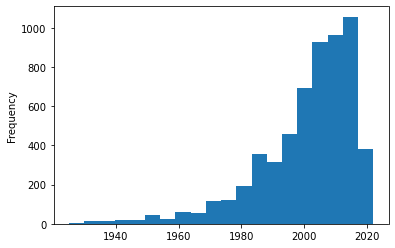

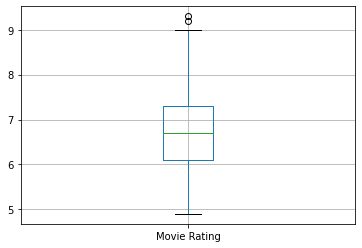

In [13]:
#use plt to draw the diagram
df['Year of Release'].plot.hist(bins=20)
plt.show()
df.boxplot(column='Movie Rating')
plt.show()

In [14]:
#show all the movie in different
value_counts = df['Year of Release'].value_counts()
value_counts

2014    228
2016    213
2011    209
2006    208
2017    207
       ... 
1944      1
1949      1
1936      1
1938      1
1928      1
Name: Year of Release, Length: 95, dtype: int64

In [15]:
#create a data copy
df_copy = df.copy() 

#choos the column
df_copy['Year of Release'] = pd.to_numeric(df_copy['Year of Release'], errors='coerce')
#set different time point
bins = [1900, 1980, 2000, 2020]
labels = ['1900-1980', '1980-2000', '2000-2020']

df_copy.loc[:, 'decade'] = pd.cut(df_copy['Year of Release'], bins=bins, labels=labels, include_lowest=True)
#give result
decade_counts = df_copy['decade'].value_counts()
decade_counts

2000-2020    3639
1980-2000    1633
1900-1980     544
Name: decade, dtype: int64

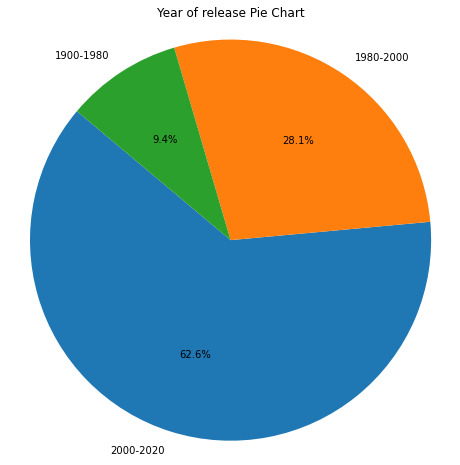

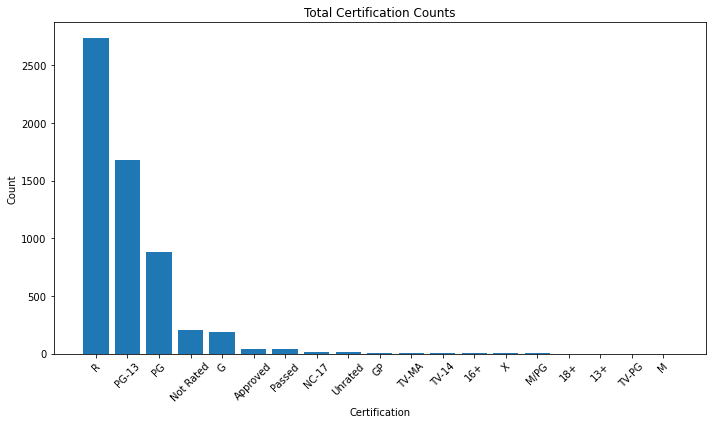

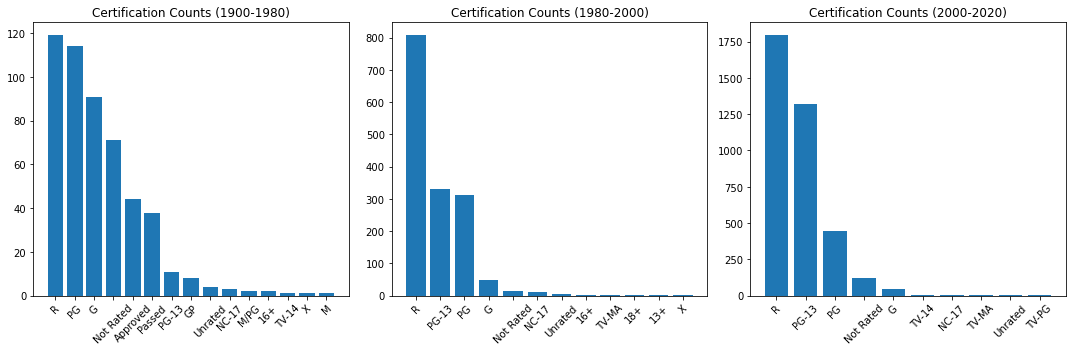

In [16]:
#use pan chart to find the percentage of differend decade
plt.figure(figsize=(8, 8))
plt.pie(decade_counts, labels=decade_counts.index, autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Year of release Pie Chart')
plt.show()

#calculate the total number of different level movie
certification_counts = df['Certification'].value_counts()
plt.figure(figsize=(10, 6))  
plt.bar(certification_counts.index, certification_counts.values)

#draw the diagram and give title
plt.xlabel('Certification')
plt.ylabel('Count')
plt.title('Total Certification Counts')


plt.xticks(rotation=45)  
plt.tight_layout() 
plt.show()
#show the data in different decade
df_1900_1980 = df[(df['Year of Release'] >= 1900) & (df['Year of Release'] < 1980)]
df_1980_2000 = df[(df['Year of Release'] >= 1980) & (df['Year of Release'] < 2000)]
df_2000_2020 = df[(df['Year of Release'] >= 2000) & (df['Year of Release'] < 2020)]

# calculate different'certification' value number
certification_counts_1900_1980 = df_1900_1980['Certification'].value_counts()
certification_counts_1980_2000 = df_1980_2000['Certification'].value_counts()
certification_counts_2000_2020 = df_2000_2020['Certification'].value_counts()

# create 3 diagram
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# histogram 1900-1980
axes[0].bar(certification_counts_1900_1980.index, certification_counts_1900_1980.values)
axes[0].set_title('Certification Counts (1900-1980)')
axes[0].tick_params(axis='x', rotation=45)  # Rotate x-axis tick labels.

#  histogram 1980-2000
axes[1].bar(certification_counts_1980_2000.index, certification_counts_1980_2000.values)
axes[1].set_title('Certification Counts (1980-2000)')
axes[1].tick_params(axis='x', rotation=45)  # Rotate x-axis tick labels.

#  histogram 2000-2020
axes[2].bar(certification_counts_2000_2020.index, certification_counts_2000_2020.values)
axes[2].set_title('Certification Counts (2000-2020)')
axes[2].tick_params(axis='x', rotation=45)  # Rotate x-axis tick labels.

plt.tight_layout()
plt.show()

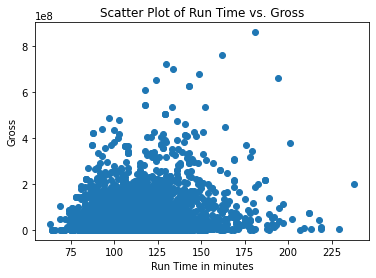

In [17]:
#create a scatter plot about the movie length and gross
plt.scatter(df['Run Time in minutes'], df['Gross'])
plt.xlabel('Run Time in minutes')
plt.ylabel('Gross')
plt.title('Scatter Plot of Run Time vs. Gross')
plt.show()


## 7. Exploratory Data Analysis

Explore movie distributions and trends.


In [18]:
#use scikit-learn to perform linear regression 
from sklearn.linear_model import LinearRegression

X = df['Run Time in minutes'].values.reshape(-1, 1)
y = df['Gross'].values

model = LinearRegression()
model.fit(X, y)


print(f'Intercept: {model.intercept_}')
print(f'Slope (Coefficient): {model.coef_}')

Intercept: -38945984.74939776
Slope (Coefficient): [782879.87228534]


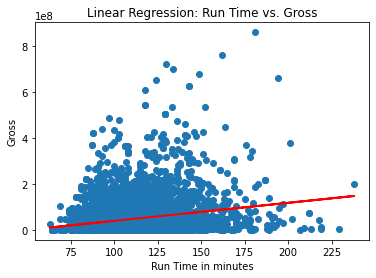

In [19]:
#linear regression model
plt.scatter(df['Run Time in minutes'], df['Gross'])
plt.plot(X, model.predict(X), color='red', linewidth=2)
plt.xlabel('Run Time in minutes')
plt.ylabel('Gross')
plt.title('Linear Regression: Run Time vs. Gross')
plt.show()

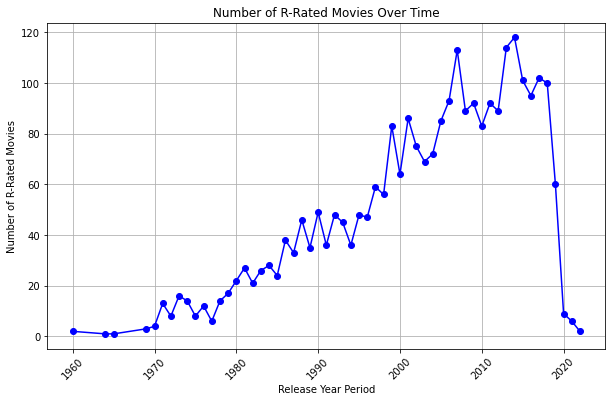

In [20]:
# create a new df store the data
r_rated_df = df[df['Certification'] == 'R']

# analysis the r level movie
r_rated_counts = r_rated_df['Year of Release'].value_counts().sort_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(r_rated_counts.index, r_rated_counts.values, marker='o', linestyle='-', color='b')
plt.xlabel('Release Year Period')
plt.ylabel('Number of R-Rated Movies')
plt.title('Number of R-Rated Movies Over Time')
plt.xticks(rotation=45)
plt.grid(True)  
plt.show()


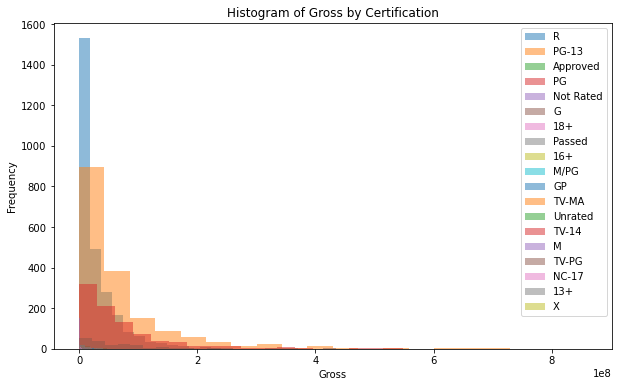

In [21]:
#creates a histogram of the 'Gross' values, grouped by different 'Certification' categories
plt.figure(figsize=(10, 6))
for certification in df['Certification'].unique():
    data = df[df['Certification'] == certification]['Gross']
    plt.hist(data, bins=20, alpha=0.5, label=certification)

plt.xlabel('Gross')
plt.ylabel('Frequency')
plt.title('Histogram of Gross by Certification')
plt.legend()
plt.show()

## 8. Linear Regression

Analyse the relationship between runtime and gross revenue.


In [22]:
#select neccsary clumn
feature_columns = ["Movie Rating", "Gross"]
selected_data = joined_data.select(*feature_columns)

# Standardize the features
from pyspark.ml.feature import VectorAssembler, StandardScaler

assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
data = assembler.transform(selected_data)

scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(data)
scaled_data = scaler_model.transform(data)

# Create a K-means clustering model, assuming it should be divided into 3 clusters.
from pyspark.ml.clustering import KMeans

kmeans = KMeans().setK(3).setSeed(1)
model = kmeans.fit(scaled_data)

# Add cluster labels to the data
clustered_data = model.transform(scaled_data)
clustered_data = clustered_data.withColumnRenamed("prediction", "Cluster")

# Display the clustering results
clustered_data.show()


+------------+---------+---------------+--------------------+-------+
|Movie Rating|    Gross|       features|     scaled_features|Cluster|
+------------+---------+---------------+--------------------+-------+
|         9.3|  2.834E7|  [9.3,2.834E7]|[3.31120855523560...|      2|
|         9.2| 1.3497E8| [9.2,1.3497E8]|[3.18499807311247...|      0|
|         9.0| 5.3486E8| [9.0,5.3486E8]|[2.93257710886620...|      1|
|         9.0|   9.69E7|   [9.0,9.69E7]|[2.93257710886620...|      0|
|         9.0| 3.7785E8| [9.0,3.7785E8]|[2.93257710886620...|      1|
|         9.0|4360000.0|[9.0,4360000.0]|[2.93257710886620...|      2|
|         9.0|4360000.0|[9.0,4360000.0]|[2.93257710886620...|      2|
|         8.9| 1.0793E8| [8.9,1.0793E8]|[2.80636662674307...|      0|
|         8.8|  3.703E7|  [8.8,3.703E7]|[2.68015614461994...|      2|
|         8.8| 3.1554E8| [8.8,3.1554E8]|[2.68015614461994...|      1|
|         8.8| 2.9258E8| [8.8,2.9258E8]|[2.68015614461994...|      1|
|         8.8| 3.302

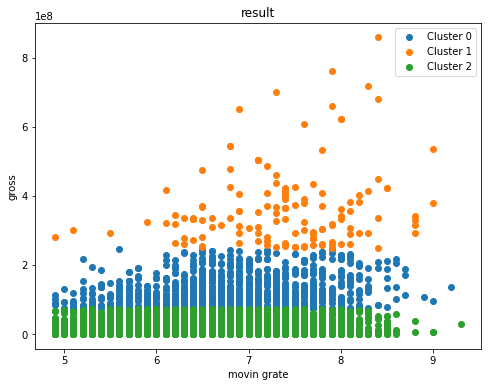

In [23]:
clustered_data = clustered_data.select("Cluster", "Movie Rating", "Gross")

# transfer to the panda frame
clustered_data_pd = clustered_data.toPandas()

# extract data
cluster0 = clustered_data_pd[clustered_data_pd["Cluster"] == 0]
cluster1 = clustered_data_pd[clustered_data_pd["Cluster"] == 1]
cluster2 = clustered_data_pd[clustered_data_pd["Cluster"] == 2]

# creat scatter diagram
plt.figure(figsize=(8, 6))
plt.scatter(cluster0["Movie Rating"], cluster0["Gross"], label="Cluster 0")
plt.scatter(cluster1["Movie Rating"], cluster1["Gross"], label="Cluster 1")
plt.scatter(cluster2["Movie Rating"], cluster2["Gross"], label="Cluster 2")

# add title and tag
plt.xlabel("movin grate")
plt.ylabel("gross")
plt.title("result")
plt.legend()

# show
plt.show()

## 9. K-Means Clustering

Cluster movies based on rating and gross revenue.


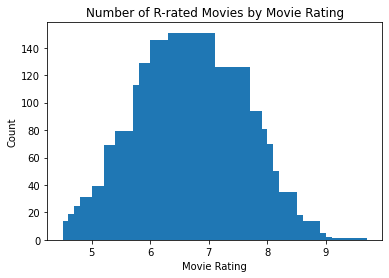

In [24]:
# analyze and visualize data
joined_data.createOrReplaceTempView("movies")
result = spark.sql("SELECT `Movie Rating`, COUNT(*) as count FROM movies WHERE Certification = 'R' GROUP BY `Movie Rating`")
result_pandas = result.toPandas()
plt.bar(result_pandas['Movie Rating'], result_pandas['count'])
plt.xlabel('Movie Rating')
plt.ylabel('Count')
plt.title('Number of R-rated Movies by Movie Rating')
plt.show()

In [25]:
joined_data.createOrReplaceTempView("movies")

# run Spark SQL quary
result = spark.sql("""
    SELECT `Movie Name`, `Movie Rating`, Certification,`Year of Release`
    FROM movies
    ORDER BY `Movie Rating` DESC
    LIMIT 10
""")

# show result
result.show(truncate=False)

data = spark.read.csv("data.csv", header=True, inferSchema=True)

# register DataFrame to be temporary table
joined_data.createOrReplaceTempView("pmovies")

# run spark quires
presult = spark.sql("""
    SELECT `Movie Name`, votes,Certification,`Year of Release`
    FROM pmovies
    ORDER BY votes DESC
    LIMIT 10
""")

# show result
presult.show(truncate=False)

+-------------------------------------------------+------------+-------------+---------------+
|Movie Name                                       |Movie Rating|Certification|Year of Release|
+-------------------------------------------------+------------+-------------+---------------+
|The Shawshank Redemption                         |9.3         |R            |1994           |
|The Godfather                                    |9.2         |R            |1972           |
|The Dark Knight                                  |9.0         |PG-13        |2008           |
|Schindler's List                                 |9.0         |R            |1993           |
|The Lord of the Rings: The Return of the King    |9.0         |PG-13        |2003           |
|12 Angry Men                                     |9.0         |Approved     |1957           |
|12 Angry Men                                     |9.0         |Approved     |1957           |
|Pulp Fiction                                     

In [27]:

from pyspark.sql.functions import explode, split, regexp_replace
# split the 'Genre' column, remove unnecessary characters, and filter by 'Certification = 'R'
split_and_clean_query = """
SELECT TRIM(BOTH '[]'' ' FROM REGEXP_REPLACE(word, "[']|(\s+)", "")) AS cleaned_word
FROM (
    SELECT explode(split(Genre, ',')) AS word
    FROM movies
    WHERE Certification = 'R'
)
"""

split_and_clean_result = spark.sql(split_and_clean_query)
split_and_clean_result.createOrReplaceTempView("cleaned_genres")

# calculate the word number
word_frequency_query = """
SELECT cleaned_word AS word, COUNT(1) AS frequency
FROM cleaned_genres
GROUP BY cleaned_word
ORDER BY frequency DESC
"""

word_frequency_result = spark.sql(word_frequency_query)
word_frequency_result.show()

+---------+---------+
|     word|frequency|
+---------+---------+
|    Drama|     1707|
|    Crime|      842|
|   Comedy|      785|
|   Action|      679|
| Thriller|      675|
|   Horror|      514|
|  Romance|      394|
|   Mytery|      384|
|Biography|      219|
|Adventure|      191|
|   Sci-Fi|      183|
|   Fantay|      149|
|     Muic|       90|
|   Hitory|       81|
|      War|       67|
|    Sport|       34|
|   Wetern|       24|
|Animation|       13|
|   Muical|       11|
+---------+---------+



## 10. Spark SQL Analytics

Perform SQL-based analytical queries.


In [ ]:
Conclusion:
Over time, people have become more accepting of R-rated movies. These films tend to be shorter in duration, 
receive ratings clustered around the mid-range, and often feature content with elements like crime to attract 
viewers. The high number of votes demonstrates their popularity among audiences.But at same time the movie length 
and their popularity is directly proportional to the gross revenue.